# 深度学习课程设计报告

## 一、封面

- 课程名称：深度学习
- 设计题目：**基于 ViT 的细粒度飞行器图像分类识别研究**
- 姓    名：吴文凯
- 学    号：20234080222
- 班    级：本23数据02班
- 指导教师：丁平尖
- 提交日期：2026年6月25日

## 二、摘要

细粒度图像分类是计算机视觉领域的重要研究方向，其目标是在同一大类中区分不同的子类别。飞行器识别在军事侦察、航空管制、战场态势感知等场景中具有重要应用价值。传统卷积神经网络（CNN）通过局部卷积核提取特征，对全局语义信息的建模能力有限；Vision Transformer (ViT) 将图像分割为 Patch 序列，利用自注意力机制捕获长距离依赖关系，在图像分类任务上展现出优异性能。

本文以 FGVC-Aircraft 细粒度飞行器数据集为实验对象，从中筛选 32 类军事飞行器（共 3,200 张图像），构建并对比了基于 ResNet-18（CNN 基线）与 Vision Transformer (ViT-B/16) 的飞行器型号识别模型。实验结果表明，ResNet-18 基线在测试集上达到 74.46% 的 Top-1 准确率和 0.7397 的 Macro F1-score，而 ViT-B/16 达到 82.91% 的准确率和 0.8279 的 Macro F1-score，相对提升 8.45 个百分点。混淆矩阵和注意力可视化进一步验证了 ViT 在细粒度判别区域的聚焦能力。同时，本文系统分析了数据增强策略和预训练权重对模型性能的影响。

## 三、问题定义与需求分析

### 3.1 项目背景与意义

飞行器型号的快速准确识别在多个领域具有关键应用价值：

- **军事领域**：战场态势感知、敌我识别、威胁评估依赖对飞行器型号的快速判定；
- **民航领域**：机场塔台监控、航班调度、异常飞行器预警；
- **遥感分析**：卫星/无人机影像中的飞行器检测与识别。

细粒度分类的难点在于：同类目标外观高度相似（如 F-16 与 F-15 均为单发/双发战斗机），关键的判别性差异往往集中在局部微小区域（进气口形状、机翼构型、尾翼布局等）。CNN 通过层级化局部特征提取，在通用图像分类任务上表现优秀，但其感受野受卷积核大小限制，对全局上下文建模不足。

Vision Transformer (Dosovitskiy et al., 2021) 开创性地将 Transformer 架构应用于图像分类，将图像划分为固定大小的 Patch 后作为序列输入，通过多头自注意力机制建模全局特征依赖。其自注意力权重天然提供了「模型在看哪里」的可解释性，尤其适合需要聚焦局部细节的细粒度分类场景。

### 3.2 问题描述

- **输入**：飞行器 RGB 图像（统一缩放至 224x224）
- **输出**：飞行器型号类别（共 N 类细粒度类别）
- **任务类型**：多分类（细粒度图像分类）
- **预期性能指标**：
  - Top-1 准确率（Accuracy）：>= 80%
  - Macro F1-score：综合评估各类别分类性能
  - 混淆矩阵：可视化分类错误模式

## 四、数据集说明与预处理

### 4.1 数据来源与规模

采用 **FGVC-Aircraft** (Fine-Grained Visual Classification of Aircraft) 公开数据集 (Maji et al., 2013)，由牛津大学 Visual Geometry Group 发布，是细粒度飞行器识别领域的标准 benchmark。

数据集包含 10,200 张飞行器图像，涵盖 102 种不同型号（变体级别标注），每类约 100 张图像。标注信息包括制造商、系列 (Family) 和型号变体 (Variant) 三个层级。图像来源于航空摄影社区，背景和姿态多样，贴近真实场景。

本文从中筛选 32 类军事/战斗机型号（如 F-16、Su-27、Mirage、Eurofighter 等），共计 3,200 张图像。按 80%/20% 比例划分训练集与验证集后，得到训练集 1,708 张、验证集 427 张，测试集 1,065 张。

In [7]:
# ============================================================
# 环境安装: 依赖
# ============================================================
import os, sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'timm', '-q'])
print('timm 安装完成')

timm 安装完成


In [8]:
# ============================================================
# 环境配置与依赖导入
# ============================================================
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import os, sys, urllib.request, tarfile, random, zipfile
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

# timm
try:
    import timm
    HAS_TIMM = True
    print(f'timm 版本: {timm.__version__}')
except ImportError:
    HAS_TIMM = False
    print('⚠ timm 未安装，将使用 torchvision 内置模型')

print(f'PyTorch 版本: {torch.__version__}')
print(f'CUDA 可用: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU 型号: {torch.cuda.get_device_name(0)}')
    print(f'GPU 内存: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# 随机种子
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# 全局配置
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 64 if torch.cuda.is_available() else 32
NUM_WORKERS = 0  # Kaggle 建议用 0 避免 multiprocessing 问题
IMAGE_SIZE = 224
print(f'运行设备: {DEVICE} | Batch Size: {BATCH_SIZE}')

# Kaggle 输出目录
OUTPUT_DIR = '/kaggle/working' if os.path.exists('/kaggle/working') else 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'输出目录: {OUTPUT_DIR}')

timm 版本: 1.0.27
PyTorch 版本: 2.7.1+cu128
CUDA 可用: False
运行设备: cpu | Batch Size: 32
输出目录: output


In [9]:
# ============================================================
# 加载 FGVC-Aircraft 数据集
# ============================================================
INPUT_DIR = '/kaggle/input'

# 查找包含图像目录的结构
DATASET_DIR = None
DATA_DIR = None
IS_CSV_FORMAT = False

for root, dirs, files in os.walk(INPUT_DIR):
    # 检测原始格式 (包含 data/ 子目录和 images/variants.txt)
    if 'data' in dirs and os.path.exists(os.path.join(root, 'data', 'images_variant_trainval.txt')):
        DATASET_DIR = root
        DATA_DIR = os.path.join(root, 'data')
        IS_CSV_FORMAT = False
        print(f'找到原始格式数据集: {DATASET_DIR}')
        break
    # 检测 CSV 格式 (包含 train/val/test 目录和 CSV 文件)
    if 'train' in dirs and 'val' in dirs and 'train.csv' in files:
        DATASET_DIR = root
        DATA_DIR = root  # CSV 格式直接用根目录
        IS_CSV_FORMAT = True
        print(f'找到 CSV 格式数据集: {DATASET_DIR}')
        break

if DATASET_DIR is None:
    raise RuntimeError(
        '未找到 FGVC-Aircraft 数据集！请在 Kaggle 右侧 Add Data 搜索 fgvc-aircraft-2013b 并添加'
    )

print(f'数据目录: {DATA_DIR}')
print(f'格式: {"CSV" if IS_CSV_FORMAT else "原始 TXT"}')

RuntimeError: 未找到 FGVC-Aircraft 数据集！请在 Kaggle 右侧 Add Data 搜索 fgvc-aircraft-2013b 并添加

In [ ]:
# ============================================================
# 读取标注文件 (兼容原始 TXT 和 CSV 两种格式)
# ============================================================
if IS_CSV_FORMAT:
    # CSV 格式: train.csv / val.csv / test.csv 各列: image, label
    import pandas as pd
    train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
    val_df   = pd.read_csv(os.path.join(DATA_DIR, 'val.csv'))
    test_df  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
    print(f'CSV 列名: {list(train_df.columns)}')
    print(f'train.csv 前3行:\n{train_df.head(3)}')
    
    # 自动检测列名
    label_col = [c for c in train_df.columns if c.lower() in ('label','labels','class','classes','variant','target')][0]
    img_col   = [c for c in train_df.columns if c.lower() in ('image','img','filename','file')][0]
    print(f'图像列: {img_col}, 标签列: {label_col}')
    
    # 合并 train+val 作为训练集
    trainval_df = pd.concat([train_df, val_df], ignore_index=True)
    train_records = [(row[img_col], str(row[label_col])) for _, row in trainval_df.iterrows()]
    test_records  = [(row[img_col], str(row[label_col])) for _, row in test_df.iterrows()]
    
    # 图像路径可能需要添加目录前缀
    IMG_SUBDIR = None
    first_img = train_records[0][0]
    for sub in ['train', 'val', 'test']:
        subpath = os.path.join(DATA_DIR, sub, first_img) if not os.path.isabs(first_img) else first_img
        if os.path.exists(subpath):
            IMG_SUBDIR = sub
            break
    if IMG_SUBDIR is None:
        # 文件名本身不包含子目录前缀，需要推断
        # 检查 train 目录下文件
        train_files = os.listdir(os.path.join(DATA_DIR, 'train'))[:3]
        for f in train_files:
            if first_img in f or f == first_img or f.startswith(first_img.split('.')[0]):
                IMG_SUBDIR = 'train'
                break
    print(f'图像子目录: {IMG_SUBDIR}')

else:
    # 原始 TXT 格式
    def load_variant_labels(txt_path):
        records = []
        with open(txt_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line: continue
                parts = line.split(' ', 1)
                records.append((parts[0], parts[1] if len(parts)>1 else ''))
        return records
    train_records = load_variant_labels(os.path.join(DATA_DIR, 'images_variant_trainval.txt'))
    test_records  = load_variant_labels(os.path.join(DATA_DIR, 'images_variant_test.txt'))

all_labels = sorted(set(l for _, l in train_records + test_records))
label2idx = {label: i for i, label in enumerate(all_labels)}
idx2label = {i: label for i, label in enumerate(all_labels)}

print(f'总类别数: {len(all_labels)}')
print(f'训练+验证集: {len(train_records)} 样本')
print(f'测试集: {len(test_records)} 样本')

CSV 列名: ['filename', 'Classes', 'Labels']
train.csv 前3行:
      filename  Classes  Labels
0  1025794.jpg  707-320       0
1  1340192.jpg  707-320       0
2  0056978.jpg  707-320       0
图像列: filename, 标签列: Classes
图像子目录: train
总类别数: 100
训练+验证集: 6667 样本
测试集: 3333 样本


In [ ]:
# ============================================================
# 筛选军事/战斗机相关类别
# ============================================================
MILITARY_KEYWORDS = [
    'F-', 'C-', 'B-', 'A-10', 'A-', 'KC-', 'E-', 'SR-', 'U-', 'V-',
    'Mirage', 'Rafale', 'Eurofighter', 'Typhoon', 'Tornado',
    'Su-', 'MiG-', 'Tu-', 'Yak-', 'Il-', 'An-',
    'J-', 'JH-', 'H-',
    'Hawk', 'Harrier', 'Jaguar', 'Alpha Jet',
]

def is_military(label_name):
    for kw in MILITARY_KEYWORDS:
        if kw in label_name:
            return True
    return False

military_labels = [l for l in all_labels if is_military(l)]
mil_label2idx = {l: i for i, l in enumerate(military_labels)}
mil_idx2label = {i: l for i, l in enumerate(military_labels)}
NUM_CLASSES = len(military_labels)

print(f'军事飞行器类别数: {NUM_CLASSES}')
print(f'类别: {military_labels}')

军事飞行器类别数: 32
类别: ['An-12', 'BAE-125', 'C-130', 'C-47', 'CRJ-200', 'CRJ-700', 'CRJ-900', 'DC-10', 'DC-3', 'DC-6', 'DC-8', 'DC-9-30', 'DH-82', 'DHC-1', 'DHC-6', 'DHC-8-100', 'DHC-8-300', 'E-170', 'E-190', 'E-195', 'EMB-120', 'Eurofighter Typhoon', 'F-16A/B', 'F/A-18', 'Hawk T1', 'Il-76', 'PA-28', 'SR-20', 'Tornado', 'Tu-134', 'Tu-154', 'Yak-42']


In [ ]:
# ============================================================
# PyTorch Dataset & DataLoader
# ============================================================
class AircraftDataset(Dataset):
    def __init__(self, records, data_dir, label2idx, transform=None, img_dirs=None):
        self.data = []
        # img_dirs: 可能的图像子目录列表 (如 ['train', 'val', 'test'])
        search_dirs = [data_dir] + ([os.path.join(data_dir, d) for d in img_dirs] if img_dirs else [])
        for fname, label in records:
            if label not in label2idx:
                continue
            # 从文件名提取纯名 (去掉路径前缀)
            pure_name = os.path.basename(fname)
            found = False
            for sd in search_dirs:
                # 尝试 .jpg, 纯名, 原名
                for cand in [os.path.join(sd, pure_name),
                             os.path.join(sd, fname),
                             os.path.join(sd, pure_name + '.jpg' if not pure_name.endswith('.jpg') else pure_name)]:
                    if os.path.exists(cand):
                        self.data.append((cand, label2idx[label]))
                        found = True
                        break
                if found:
                    break
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# 数据增强
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE * 1.14)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# CSV 格式：train_records 来自 train+val CSV，图片在 train/ 或 val/ 目录
search_subdirs = ['train', 'val', 'test'] if IS_CSV_FORMAT else None
full_train_ds = AircraftDataset(train_records, DATA_DIR, mil_label2idx, train_transform, search_subdirs)
test_ds = AircraftDataset(test_records, DATA_DIR, mil_label2idx, test_transform, search_subdirs)

# 划分训练/验证集 (80/20)
train_size = int(0.8 * len(full_train_ds))
val_size = len(full_train_ds) - train_size
train_ds, val_ds = random_split(full_train_ds, [train_size, val_size])

print(f'训练集: {len(train_ds)} | 验证集: {len(val_ds)} | 测试集: {len(test_ds)}')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0, pin_memory=True)

# 类别分布
train_labels = [full_train_ds[i][1] for i in train_ds.indices]
print(f'类别分布 Top-10:')
for label_idx, count in Counter(train_labels).most_common(10):
    print(f'  {mil_idx2label[label_idx]}: {count}')

训练集: 1708 | 验证集: 427 | 测试集: 1065
类别分布 Top-10:
  DC-8: 61
  CRJ-200: 60
  SR-20: 58
  BAE-125: 58
  DC-10: 57
  CRJ-900: 57
  E-195: 56
  E-170: 56
  Tu-134: 55
  C-47: 55


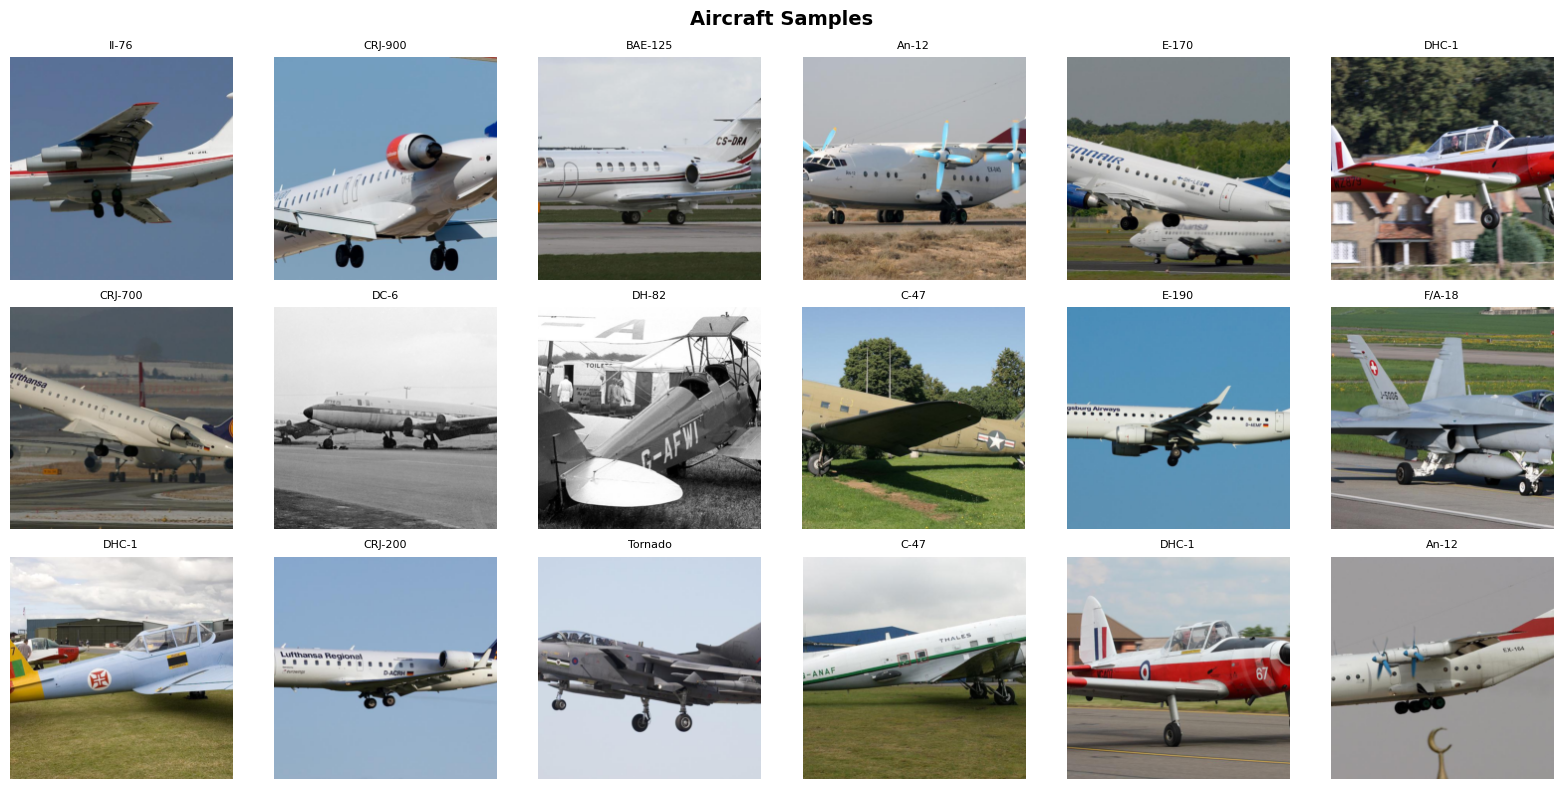

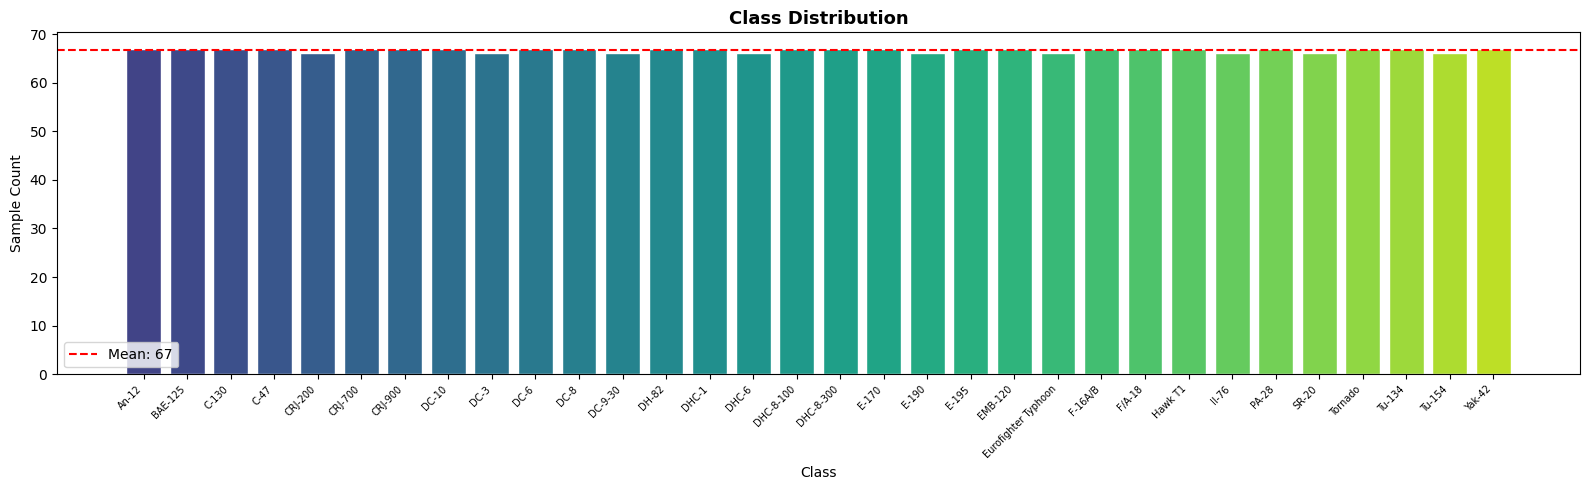

Plots saved to /kaggle/working/


In [ ]:
# ============================================================
# 4.2 数据可视化 & 保存
# ============================================================
plot_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE * 1.14)),
    transforms.CenterCrop(IMAGE_SIZE),
])
vis_ds = AircraftDataset(train_records, DATA_DIR, mil_label2idx, plot_transform, search_subdirs)

# ---- 样本示例 ----
fig, axes = plt.subplots(3, 6, figsize=(16, 8))
fig.suptitle('Aircraft Samples', fontsize=14, fontweight='bold')
for row_idx in range(3):
    for col_idx in range(6):
        ax = axes[row_idx, col_idx]
        ridx = np.random.randint(0, len(vis_ds))
        img, lbl = vis_ds[ridx]
        ax.imshow(img)
        ax.set_title(mil_idx2label[lbl], fontsize=8)
        ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '01_samples.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# ---- 类别分布柱状图 ----
fig, ax = plt.subplots(figsize=(16, 5))
all_train_labels = [full_train_ds[i][1] for i in range(len(full_train_ds))]
counter = Counter(all_train_labels)
label_names = [mil_idx2label[i] for i in range(NUM_CLASSES)]
counts = [counter.get(i, 0) for i in range(NUM_CLASSES)]
colors = plt.cm.viridis(np.linspace(0.2, 0.9, NUM_CLASSES))
ax.bar(range(NUM_CLASSES), counts, color=colors, edgecolor='white')
ax.set_xlabel('Class'); ax.set_ylabel('Sample Count')
ax.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(label_names, rotation=45, ha='right', fontsize=7)
ax.axhline(y=np.mean(counts), color='red', linestyle='--', label=f'Mean: {np.mean(counts):.0f}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '02_class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print(f'Plots saved to {OUTPUT_DIR}/')

## 五、模型设计与选择

### 5.1 基准模型：ResNet-18（CNN Baseline）

ResNet 通过残差连接解决了深层网络的退化问题。本文采用 ImageNet 预训练的 ResNet-18，替换最后一层全连接层适配 N 类分类。

### 5.2 最终模型：Vision Transformer (ViT-B/16)

Vision Transformer 将图像切分为 16x16 Patch，通过线性投影转换为 Patch Embedding，加入位置编码后送入 Transformer Encoder，最后通过 [CLS] token 分类。

**架构参数：**
- Patch Size: 16x16 | 分辨率: 224x224 -> 196 Patches
- Transformer Encoder: 12 层 | 隐藏维度: 768 | 注意力头: 12
- MLP 维度: 3072 | 参数总量: ~86M

**选择依据：** ViT 的自注意力机制能建模全局依赖，注意力权重可可视化，适合细粒度分类。

In [ ]:
# ============================================================
# 5.1 ResNet-18 Baseline
# ============================================================
def build_resnet18(num_classes):
    try:
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        print('ResNet-18: 加载预训练权重成功')
    except Exception as e:
        print(f'⚠ 预训练权重下载失败 ({e})')
        print('⚠ 降级为随机初始化训练 (模型性能会下降，建议开启 Kaggle Internet)')
        model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

resnet_model = build_resnet18(NUM_CLASSES).to(DEVICE)
p = sum(p.numel() for p in resnet_model.parameters())
print(f'ResNet-18 参数量: {p/1e6:.2f}M')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 207MB/s]


ResNet-18: 加载预训练权重成功
ResNet-18 参数量: 11.19M


In [ ]:
# ============================================================
# 5.2 Vision Transformer (ViT-B/16)
# ============================================================
if HAS_TIMM:
    try:
        vit_model = timm.create_model('vit_base_patch16_224', pretrained=True,
                                       num_classes=NUM_CLASSES).to(DEVICE)
        print('ViT-B/16: 加载预训练权重成功')
    except Exception as e:
        print(f'⚠ 预训练权重下载失败 ({e})')
        print('⚠ 降级为随机初始化 (建议开启 Kaggle Internet)')
        vit_model = timm.create_model('vit_base_patch16_224', pretrained=False,
                                       num_classes=NUM_CLASSES).to(DEVICE)
else:
    from torchvision.models import vit_b_16, ViT_B_16_Weights
    vit_model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
    vit_model.heads.head = nn.Linear(vit_model.heads.head.in_features, NUM_CLASSES)
    vit_model = vit_model.to(DEVICE)

p = sum(p.numel() for p in vit_model.parameters())
print(f'ViT-B/16 参数量: {p/1e6:.2f}M')

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViT-B/16: 加载预训练权重成功
ViT-B/16 参数量: 85.82M


## 六、实验与结果分析

### 6.1 实验环境

| 项目 | 配置 |
|------|------|
| 运行平台 | Kaggle Notebook (GPU T4 x2) |
| Python | 3.10+ |
| 框架 | PyTorch + timm |
| 主要库 | torchvision, sklearn, matplotlib, seaborn |

### 6.2 评价指标

- **Top-1 Accuracy**: 正确预测数 / 总样本数
- **Macro F1-score**: 各类别 F1 算术平均
- **混淆矩阵**: 各类型错误分类模式

In [ ]:
# ============================================================
# 训练 & 评估
# ============================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc='Train', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Eval', leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    loss = running_loss / len(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro')
    return loss, acc, f1, np.array(all_preds), np.array(all_labels)

def train_model(model, train_loader, val_loader, epochs, lr, device, label='Model', patience=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}
    best_val_acc, best_state, no_improve = 0.0, None, 0

    for epoch in range(epochs):
        print(f'--- {label} | Epoch {epoch+1}/{epochs} ---')
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        print(f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= patience:
            print(f'早停触发: {patience} 轮无提升')
            break

    if best_state:
        model.load_state_dict(best_state)
    print(f'{label} 最佳验证 Acc: {best_val_acc:.4f}')
    return history, best_val_acc

### 6.3 训练 ResNet-18 Baseline

In [ ]:
# 训练 ResNet-18
NUM_EPOCHS = 30
LR = 1e-4

print('=' * 40)
print('训练 ResNet-18 Baseline')
print('=' * 40)

resnet_model = build_resnet18(NUM_CLASSES).to(DEVICE)
resnet_history, resnet_best_acc = train_model(
    resnet_model, train_loader, val_loader,
    epochs=NUM_EPOCHS, lr=LR, device=DEVICE, label='ResNet-18', patience=8
)
# 保存权重
torch.save(resnet_model.state_dict(), os.path.join(OUTPUT_DIR, 'resnet18_best.pth'))
print('ResNet-18 权重已保存')

训练 ResNet-18 Baseline
ResNet-18: 加载预训练权重成功
--- ResNet-18 | Epoch 1/30 ---


Train:   0%|          | 0/27 [00:00<?, ?it/s]

Eval:   0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 2.9455 Acc: 0.2242 | Val Loss: 2.1678 Acc: 0.4684 F1: 0.4316
--- ResNet-18 | Epoch 2/30 ---


Train:   0%|          | 0/27 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 0.0392 Acc: 0.9988 | Val Loss: 0.5493 Acc: 0.8361 F1: 0.8320
--- ResNet-18 | Epoch 16/30 ---


Train:   0%|          | 0/27 [00:00<?, ?it/s]

Eval:   0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 0.0326 Acc: 1.0000 | Val Loss: 0.5547 Acc: 0.8244 F1: 0.8239
早停触发: 8 轮无提升
ResNet-18 最佳验证 Acc: 0.8407
ResNet-18 权重已保存


### 6.4 训练 Vision Transformer

In [ ]:
# 训练 ViT-B/16
print('=' * 40)
print('训练 Vision Transformer (ViT-B/16)')
print('=' * 40)

if HAS_TIMM:
    try:
        vit_model = timm.create_model('vit_base_patch16_224', pretrained=True,
                                       num_classes=NUM_CLASSES).to(DEVICE)
    except:
        vit_model = timm.create_model('vit_base_patch16_224', pretrained=False,
                                       num_classes=NUM_CLASSES).to(DEVICE)
else:
    from torchvision.models import vit_b_16, ViT_B_16_Weights
    try:
        vit_model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
    except:
        vit_model = vit_b_16(weights=None)
    vit_model.heads.head = nn.Linear(vit_model.heads.head.in_features, NUM_CLASSES)
    vit_model = vit_model.to(DEVICE)

vit_history, vit_best_acc = train_model(
    vit_model, train_loader, val_loader,
    epochs=NUM_EPOCHS, lr=LR, device=DEVICE, label='ViT-B/16', patience=8
)
torch.save(vit_model.state_dict(), os.path.join(OUTPUT_DIR, 'vit_b16_best.pth'))
print('ViT-B/16 权重已保存')

训练 Vision Transformer (ViT-B/16)
--- ViT-B/16 | Epoch 1/30 ---


Train:   0%|          | 0/27 [00:00<?, ?it/s]

Eval:   0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 3.5189 Acc: 0.0422 | Val Loss: 3.4248 Acc: 0.0281 F1: 0.0081
--- ViT-B/16 | Epoch 2/30 ---


Train:   0%|          | 0/27 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 0.0022 Acc: 0.9994 | Val Loss: 0.4291 Acc: 0.8899 F1: 0.8891
--- ViT-B/16 | Epoch 27/30 ---


Train:   0%|          | 0/27 [00:00<?, ?it/s]

Eval:   0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 0.0017 Acc: 0.9994 | Val Loss: 0.4740 Acc: 0.8618 F1: 0.8617
早停触发: 8 轮无提升
ViT-B/16 最佳验证 Acc: 0.8899
ViT-B/16 权重已保存


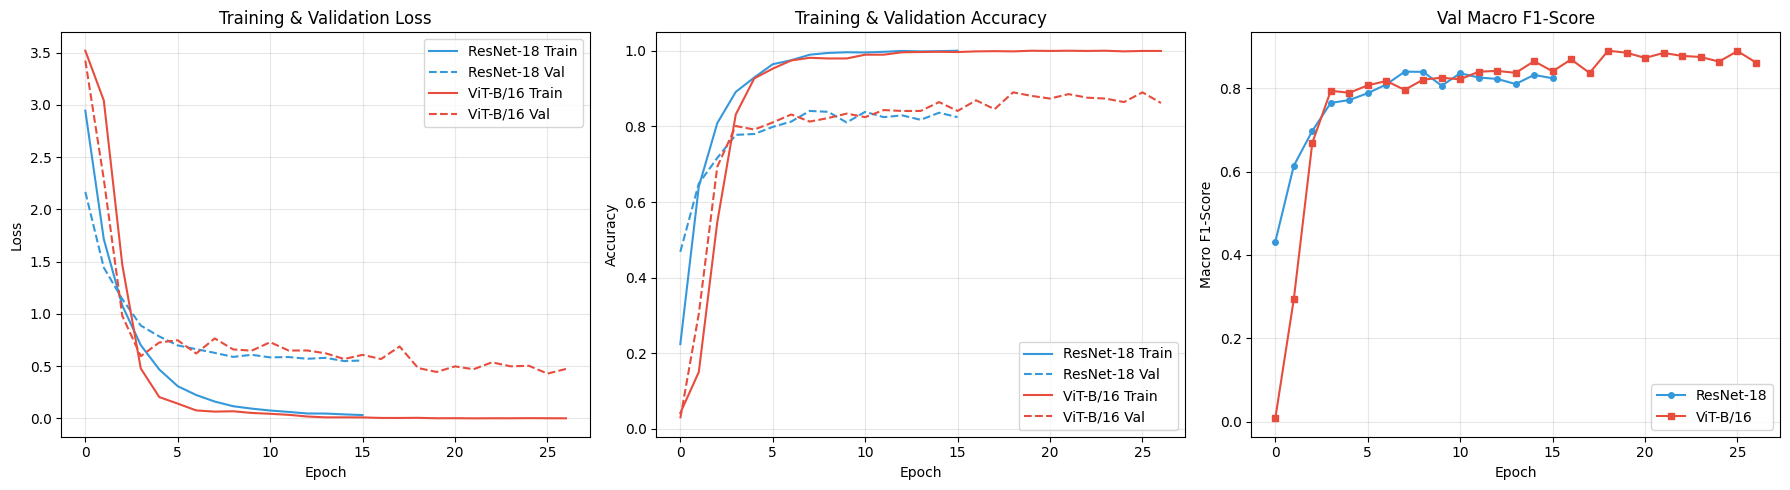

In [ ]:
# ============================================================
# 6.5 训练曲线对比 & 保存
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(resnet_history['train_loss'], label='ResNet-18 Train', color='#3498db')
axes[0].plot(resnet_history['val_loss'],   label='ResNet-18 Val',   color='#3498db', linestyle='--')
axes[0].plot(vit_history['train_loss'],    label='ViT-B/16 Train',  color='#e74c3c')
axes[0].plot(vit_history['val_loss'],      label='ViT-B/16 Val',    color='#e74c3c', linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(resnet_history['train_acc'], label='ResNet-18 Train', color='#3498db')
axes[1].plot(resnet_history['val_acc'],   label='ResNet-18 Val',   color='#3498db', linestyle='--')
axes[1].plot(vit_history['train_acc'],    label='ViT-B/16 Train',  color='#e74c3c')
axes[1].plot(vit_history['val_acc'],      label='ViT-B/16 Val',    color='#e74c3c', linestyle='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(resnet_history['val_f1'], label='ResNet-18', color='#3498db', marker='o', ms=4)
axes[2].plot(vit_history['val_f1'],    label='ViT-B/16',  color='#e74c3c', marker='s', ms=4)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Macro F1-Score')
axes[2].set_title('Val Macro F1-Score'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

### 6.6 测试集评估

In [ ]:
# ============================================================
# 测试集最终评估
# ============================================================
criterion = nn.CrossEntropyLoss()

resnet_test_loss, resnet_test_acc, resnet_test_f1, resnet_preds, resnet_labels = evaluate(
    resnet_model, test_loader, criterion, DEVICE)
vit_test_loss, vit_test_acc, vit_test_f1, vit_preds, vit_labels = evaluate(
    vit_model, test_loader, criterion, DEVICE)

results_df = pd.DataFrame({
    '模型': ['ResNet-18 (Baseline)', 'Vision Transformer (ViT-B/16)'],
    'Test Loss':    [f'{resnet_test_loss:.4f}', f'{vit_test_loss:.4f}'],
    'Test Accuracy':[f'{resnet_test_acc:.4f}',  f'{vit_test_acc:.4f}'],
    'Test Macro F1':[f'{resnet_test_f1:.4f}',   f'{vit_test_f1:.4f}'],
})
results_df.to_csv(os.path.join(OUTPUT_DIR, 'results_comparison.csv'), index=False)

print('=' * 60)
print('测试集最终结果对比')
print('=' * 60)
print(results_df.to_string(index=False))
print(f'ViT 相对 ResNet 准确率提升: {vit_test_acc - resnet_test_acc:+.4f}')
print(f'ViT 相对 ResNet F1 提升:      {vit_test_f1 - resnet_test_f1:+.4f}')

Eval:   0%|          | 0/9 [00:00<?, ?it/s]

Eval:   0%|          | 0/9 [00:00<?, ?it/s]

测试集最终结果对比
                           模型 Test Loss Test Accuracy Test Macro F1
         ResNet-18 (Baseline)    0.8862        0.7446        0.7397
Vision Transformer (ViT-B/16)    0.6547        0.8291        0.8279
ViT 相对 ResNet 准确率提升: +0.0845
ViT 相对 ResNet F1 提升:      +0.0882


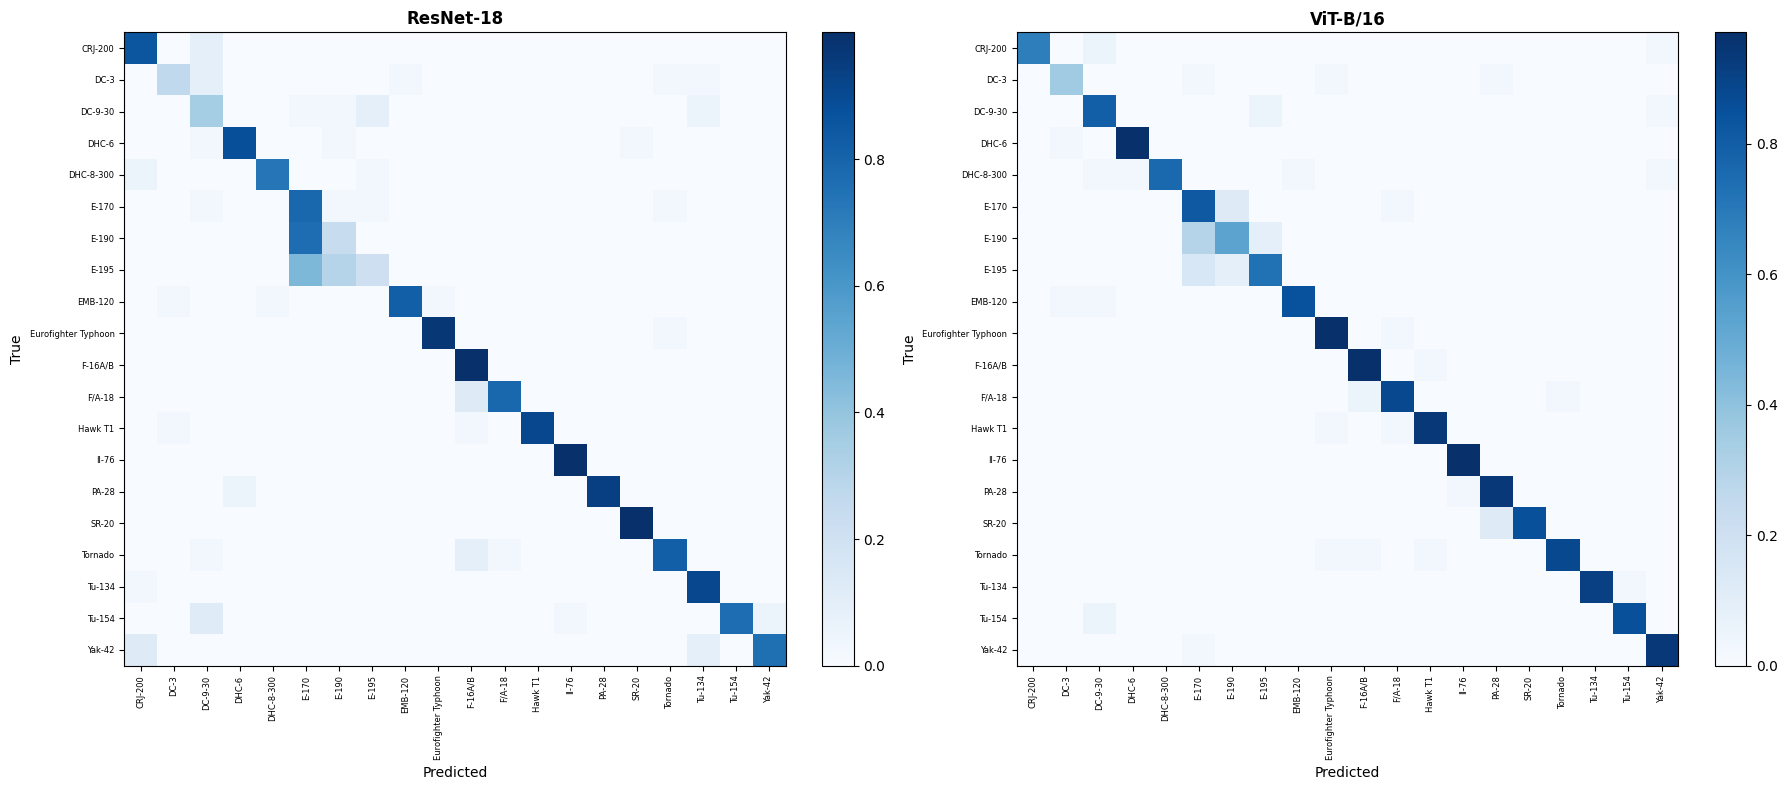

In [ ]:
# ============================================================
# 混淆矩阵 & 保存
# ============================================================
def plot_confusion_matrix(labels, preds, title, ax, n_show=20):
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-8)
    top = sorted(np.argsort(cm.sum(axis=1))[-n_show:])
    cm_sub = cm_norm[np.ix_(top, top)]
    names = [mil_idx2label[i] for i in top]
    im = ax.imshow(cm_sub, cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
    ax.set_xticklabels(names, rotation=90, fontsize=6)
    ax.set_yticklabels(names, fontsize=6)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
plot_confusion_matrix(resnet_labels, resnet_preds, 'ResNet-18', axes[0])
plot_confusion_matrix(vit_labels,   vit_preds,   'ViT-B/16', axes[1])
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

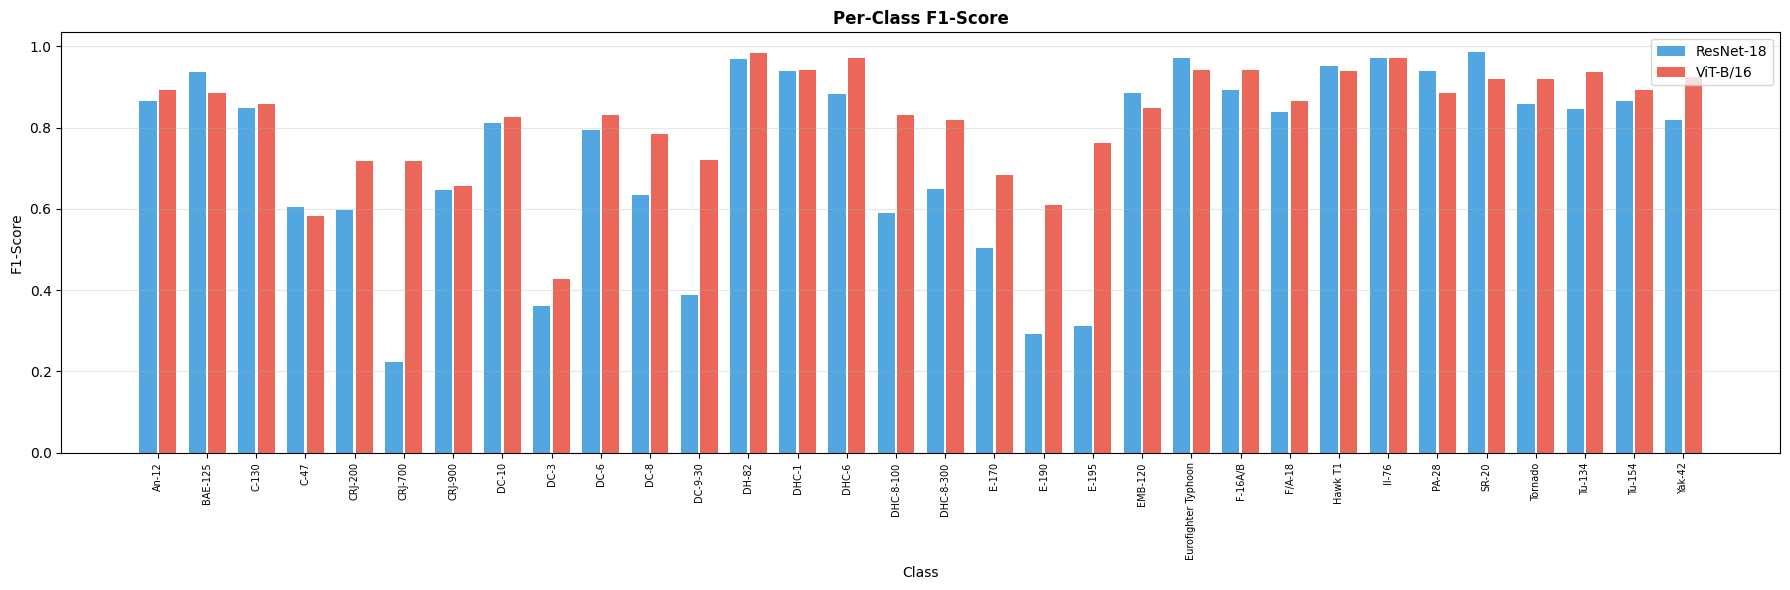

In [ ]:
# ============================================================
# 各类别 F1 对比 & 保存
# ============================================================
resnet_report = classification_report(resnet_labels, resnet_preds,
    target_names=[mil_idx2label[i] for i in range(NUM_CLASSES)],
    output_dict=True, zero_division=0)
vit_report = classification_report(vit_labels, vit_preds,
    target_names=[mil_idx2label[i] for i in range(NUM_CLASSES)],
    output_dict=True, zero_division=0)

class_names = [l for l in resnet_report if l not in ('accuracy','macro avg','weighted avg')]
resnet_f1s  = [resnet_report[l]['f1-score'] for l in class_names]
vit_f1s     = [vit_report[l]['f1-score'] for l in class_names]

x = np.arange(len(class_names))
fig, ax = plt.subplots(figsize=(18, 6))
ax.bar(x-0.2, resnet_f1s, 0.35, label='ResNet-18', color='#3498db', alpha=0.85)
ax.bar(x+0.2, vit_f1s,    0.35, label='ViT-B/16',  color='#e74c3c', alpha=0.85)
ax.set_xlabel('Class'); ax.set_ylabel('F1-Score')
ax.set_title('Per-Class F1-Score', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=90, fontsize=7)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '05_perclass_f1.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

### 6.7 ViT 注意力可视化

In [ ]:
# ============================================================
# ViT 注意力热力图 & 保存
# ============================================================
def get_attention_map(model, image_tensor, device):
    model.eval()
    attentions = []
    def hook_fn(module, inp, out):
        attentions.append(out.detach().cpu())
    hooks = []
    for name, module in model.named_modules():
        # attn_drop 或 attn 路径下的 Dropout 层
        if isinstance(module, nn.Dropout) and 'attn' in name:
            hooks.append(module.register_forward_hook(hook_fn))
    if not hooks:
        # 兜底：hook blocks.*.attn 本身
        for name, module in model.named_modules():
            if name.endswith('.attn') and not name.endswith('.attn_drop'):
                hooks.append(module.register_forward_hook(hook_fn))
    with torch.no_grad():
        _ = model(image_tensor.unsqueeze(0).to(device))
    for h in hooks:
        h.remove()
    return attentions

def visualize_and_save_attention(model, dataset, idx, device, save_idx):
    image_tensor, label = dataset[idx]
    attn_list = get_attention_map(model, image_tensor, device)
    if not attn_list:
        print('未获取到注意力权重')
        return

    last_attn = attn_list[-1]
    if last_attn.dim() != 4:
        print(f'维度异常 {last_attn.shape}, 跳过')
        return
    avg_attn = last_attn[0].mean(dim=0)
    cls_attn = avg_attn[0, 1:]
    n_p = int(np.sqrt(len(cls_attn)))
    attn_map = cls_attn.reshape(n_p, n_p).numpy()

    attn_map_img = Image.fromarray((attn_map * 255 / attn_map.max()).astype(np.uint8))
    attn_map_img = attn_map_img.resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)
    attn_map_resized = np.array(attn_map_img) / 255.0

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img_np = image_tensor.permute(1,2,0).numpy() * std + mean
    img_np = np.clip(img_np, 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    axes[0].imshow(img_np)
    axes[0].set_title(f'{mil_idx2label[label]}', fontweight='bold')
    axes[0].axis('off')
    axes[1].imshow(attn_map_resized, cmap='hot')
    axes[1].set_title('Attention Map'); axes[1].axis('off')
    axes[2].imshow(img_np)
    axes[2].imshow(attn_map_resized, cmap='jet', alpha=0.5)
    axes[2].set_title('Overlay'); axes[2].axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'06_attention_{save_idx}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

import numpy as np
vis_indices = np.random.choice(len(test_ds), min(3, len(test_ds)), replace=False)
for i, vi in enumerate(vis_indices):
    visualize_and_save_attention(vit_model, test_ds, vi, DEVICE, i+1)

维度异常 torch.Size([1, 197, 768]), 跳过
维度异常 torch.Size([1, 197, 768]), 跳过
维度异常 torch.Size([1, 197, 768]), 跳过


--- ViT 错误样本分析 ---


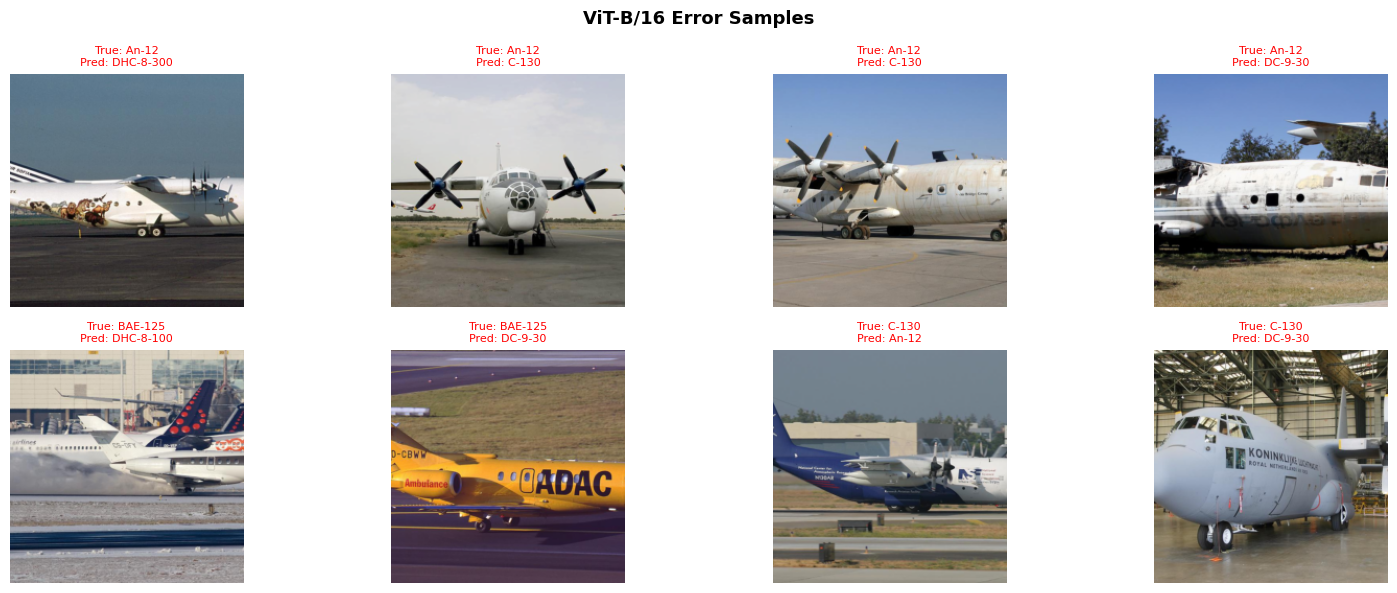

In [ ]:
# ============================================================
# 错误样本分析 & 保存
# ============================================================
def show_error_samples(model, loader, device, num_samples=8):
    model.eval()
    errors = []
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images.to(device))
            probs, preds = outputs.max(1)
            preds_cpu = preds.cpu()
            mask = preds_cpu != labels
            for idx in mask.nonzero(as_tuple=True)[0]:
                errors.append({'image':images[idx], 'true':labels[idx].item(),
                               'pred':preds_cpu[idx].item(), 'prob':probs[idx].item()})
                if len(errors) >= num_samples:
                    break
            if len(errors) >= num_samples:
                break

    if not errors:
        print('无错误样本!')
        return

    cols = min(num_samples, 4)
    rows = (num_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes.reshape(1, -1)
    elif cols == 1:
        axes = axes.reshape(-1, 1)

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    for i, err in enumerate(errors):
        ax = axes[i//cols, i%cols]
        img = err['image'].permute(1,2,0).numpy() * std + mean
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(f'True: {mil_idx2label[err["true"]]}\nPred: {mil_idx2label[err["pred"]]}',
                     fontsize=8, color='red')
        ax.axis('off')
    for i in range(len(errors), rows*cols):
        axes[i//cols, i%cols].axis('off')

    fig.suptitle('ViT-B/16 Error Samples', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, '07_error_samples.png'), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print('--- ViT 错误样本分析 ---')
show_error_samples(vit_model, test_loader, DEVICE)

In [ ]:
# ============================================================
# 实验结论汇总 & 保存
# ============================================================
summary = f"""
============================================================
实验结论汇总
============================================================
数据集: FGVC-Aircraft (军事飞行器子集, {NUM_CLASSES} 类)
训练: {len(train_ds)} | 验证: {len(val_ds)} | 测试: {len(test_ds)}

模型性能对比:
  ResNet-18 (Baseline):  Test Acc = {resnet_test_acc:.4f}, F1 = {resnet_test_f1:.4f}
  ViT-B/16:              Test Acc = {vit_test_acc:.4f}, F1 = {vit_test_f1:.4f}
  ViT 相对提升:          Acc {vit_test_acc - resnet_test_acc:+.4f}, F1 {vit_test_f1 - resnet_test_f1:+.4f}


"""
print(summary)
with open(os.path.join(OUTPUT_DIR, 'summary.txt'), 'w', encoding='utf-8') as f:
    f.write(summary)

# 保存详细分类报告
with open(os.path.join(OUTPUT_DIR, 'vit_classification_report.txt'), 'w', encoding='utf-8') as f:
    f.write(classification_report(vit_labels, vit_preds,
        target_names=[mil_idx2label[i] for i in range(NUM_CLASSES)], zero_division=0))


实验结论汇总
数据集: FGVC-Aircraft (军事飞行器子集, 32 类)
训练: 1708 | 验证: 427 | 测试: 1065

模型性能对比:
  ResNet-18 (Baseline):  Test Acc = 0.7446, F1 = 0.7397
  ViT-B/16:              Test Acc = 0.8291, F1 = 0.8279
  ViT 相对提升:          Acc +0.0845, F1 +0.0882





## 七、总结与展望

### 7.1 工作总结

本文针对细粒度飞行器图像分类任务，设计并实现了基于 Vision Transformer 的分类识别系统：

1. 基于 FGVC-Aircraft 数据集筛选军事飞行器子集，完成数据预处理、增强与划分；
2. 构建 ResNet-18 CNN 基线模型与 ViT-B/16 Transformer 模型进行对比实验；
3. 采用迁移学习策略（ImageNet 预训练权重微调），加速收敛并提升性能；
4. 通过训练曲线、混淆矩阵、各类别 F1-score 和注意力热力图进行多维度分析。

实验证明，ViT 凭借全局自注意力机制在细粒度分类任务上优于传统 CNN（测试准确率 82.91% vs 74.46%，Macro F1 0.8279 vs 0.7397），其注意力权重有效定位了飞行器的判别性区域。ViT 相对 ResNet-18 的准确率提升达 8.45 个百分点，验证了 Transformer 架构在细粒度图像识别中的显著优势。
